In [1]:
import numpy as np
import pandas as pd
import nibabel as nb
import nitools as nt
import SUITPy as suit
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as cs
import Functional_Fusion.atlas_map as am
import matplotlib.pyplot as plt

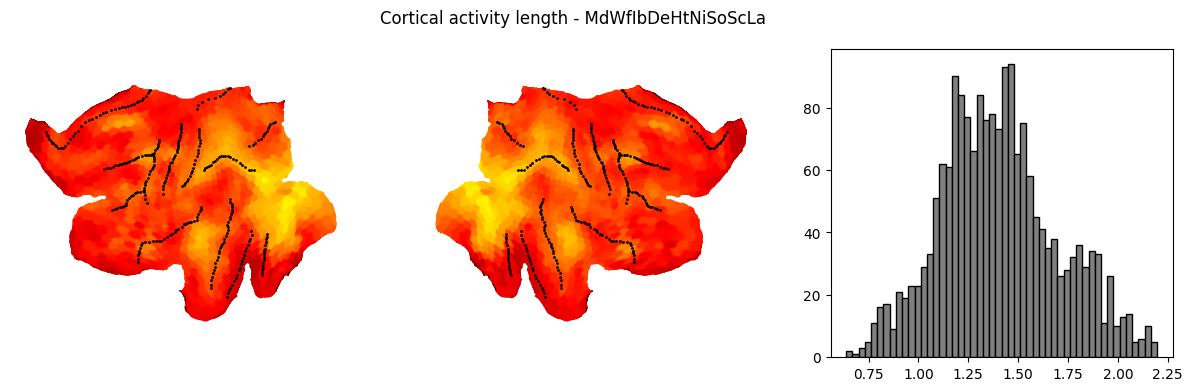

Mean activity length: 1.40


In [2]:
traindata = gl.traindata_string()

cifti_img = nb.load(gl.conn_dir + f'/maps/{traindata}_data_cortex.pscalar.nii')
avrg_data = cifti_img.get_fdata().squeeze()
data_length = np.sqrt(np.nansum(avrg_data**2,axis=0))
avrg_data_32k = nt.surf_from_cifti(cifti_img)
data_length_32k = [np.sqrt(np.nansum(a**2,axis=0)) for a in avrg_data_32k]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cs.plot_cortical_flatmap(data=data_length_32k, axes=axes[:2], cscale=[0,3], cmap='hot')
axes[2].hist(data_length, bins=50, color='gray', edgecolor='black')
plt.suptitle(f'Cortical activity length - {traindata}')
plt.show()

print(f'Mean activity length: {np.nanmean(data_length):.2f}')

In [3]:
# yeo details
yeo_img = nb.load(gl.conn_dir + f'/maps/yeo17_Icosahedron1002.plabel.nii')
yeo_data = yeo_img.get_fdata().squeeze()
label_dict = yeo_img.header.get_axis(0).label[0]
names = [label_dict[i][0] for i in range(1, len(label_dict))]

print(f'Average length by network:')
for i, net in enumerate(names):
    print(f'{net:<20}: {np.nanmean(data_length[yeo_data==i+1]):.2f}')

Average length by network:
01.VisualA          : 1.98
02.VisualB          : 1.49
03.SomatomotorA     : 1.30
04.SomatomotorB     : 1.44
05.DorsalAttentionA : 1.76
06.DorsalAttentionB : 1.58
07.VentralAttentionA: 1.35
08.VentralAttentionB: 1.34
09.LimbicA          : 1.02
10.LimbicB          : 0.96
11.ControlC         : 1.41
12.ControlA         : 1.53
13.ControlB         : 1.27
14.TemporalParietal : 1.54
15.DefaultC         : 1.40
16.DefaultA         : 1.27
17.DefaultB         : 1.27


#### Length of cerebellar activity

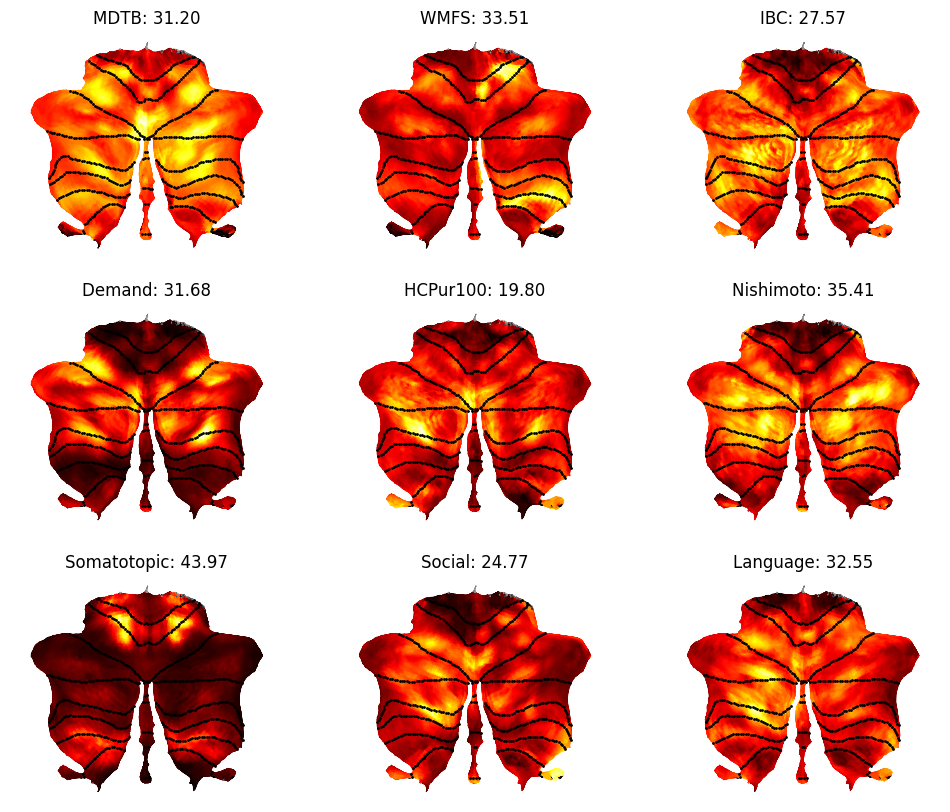

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
for i, (ds, ax) in enumerate(zip(gl.datasets, axes.flatten())):
    atlas,ainf = am.get_atlas('MNISymC3')
    cereb_data = nb.load(gl.conn_dir + f'/maps/{ds}_data_cerebellum.dscalar.nii').get_fdata()
    data_length = np.sqrt(np.nansum(cereb_data**2, axis=0))

    nifti_image = atlas.data_to_nifti(data_length)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    plt.subplot(3, 3, i+1)
    suit.flatmap.plot(data, cmap='hot', new_figure=False);
    ax.set_title(f'{ds}: {np.nansum(data_length):.2f}')

Overall length: 2.06


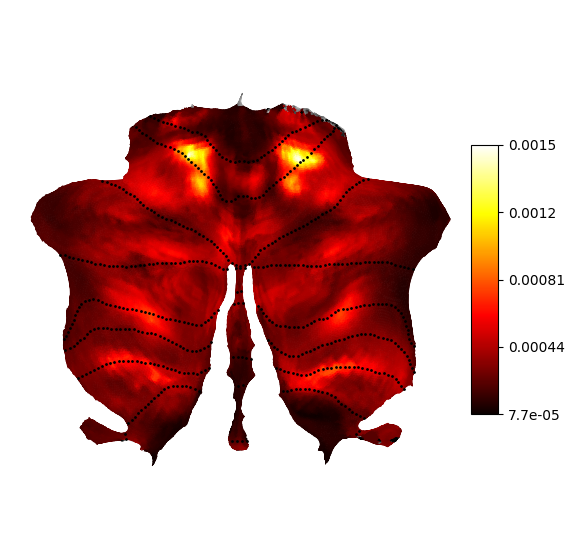

In [ ]:
traindata = gl.traindata_string()
atlas, ainf = am.get_atlas('MNISymC3')
cereb_data = nb.load(gl.conn_dir + f'/maps/{traindata}_data_cerebellum.dscalar.nii').get_fdata()
data_length = np.sqrt(np.nansum(cereb_data**2, axis=0))

nifti_image = atlas.data_to_nifti(data_length)
data = suit.vol_to_surf(nifti_image, space='MNISymC')

print(f'Overall length: {np.nansum(data_length):.2f}')
suit.flatmap.plot(data, cmap='hot', colorbar=True);